<b><font size="6"> Cars 4 You: Predicting Car Values with ML </font></b><br><br>

`Group 40`

Ana Macedo (20250405)<br>
Catarina Mendinhas (20250422)<br>
Lourenço Silva (20250453)<br>
Maria Fonseca (20250380)<br>

# Import Libraries

The following libraries will help us develop the analyses and model for this project. Pandas and Numpy, provide the efficient tools for data manipulation, cleaning and numerical computations. Matplotlib and Seaborn are used to create clear and informative visualizations. Scikit-learn offers a range of Machine Learning tools for model training, spliting the data and evaluate model performance. Finally, os, math and ceil are imported to support file management and mathematical operations.

In [222]:
import pandas as pd 
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import os

#linear regression
from sklearn.linear_model import LinearRegression

#ridge, lasso, elastic net regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

#model evaluation
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, median_absolute_error, mean_absolute_percentage_error
import statsmodels.api as sm

# Create Meta Data

Understanding the features helps interpret the data correctly and supports subsequent analysis and modeling steps. This section provides a brief description of each feature in the dataset, explaining its meaning and type.

**carID:** An atribute that contains an identifier for each car.

**Brand:** The cars main brand (e.g., Ford, Toyota).

**model:** The car model.

**year:** The year of registration of the car.

**price:** The car's price when purchased by Cars 4 You (in £).

**transmission:** The car's type of transmission.

**mileage:** The total reported distance travelled by the car (in miles).

**fuelType:** Type of Fuel used by car (Diesel, Petrol, Hybrid, Electric).

**tax:** The amount of road tax (in £) that, in 2020, was applicable to the car in question.

**mpg:** Average Miles per Gallon.

**engineSize:** Size of Engine in liters (Cubic Decimeters).

**paintQuality%** The mechanic’s assessment of the cars’ overall paint quality and hull integrity (filled by the mechanic during evaluation). 

**previousOwner:** Number of previous registered owners of the vehicle.

**hasDamage:** Boolean marker filled by the seller at the time of registration stating whether the car is damaged or not.



# Import Dataset

In this section, we load the preprocessed datasets that were previously saved after the data preprocessing steps. These datasets are ready for feature selection and further analysis.

In [205]:
# Define relative path to the preprocessed data folder (outside "notebooks/")
data_path = "../data_feature_selected/"

# Load preprocessed datasets
X_train = pd.read_csv(f"{data_path}X_train_final.csv")
X_val   = pd.read_csv(f"{data_path}X_val_final.csv")
test    = pd.read_csv(f"{data_path}test_final.csv")

y_train = pd.read_csv(f"{data_path}y_train.csv").squeeze()  # convert DataFrame → Series
y_val   = pd.read_csv(f"{data_path}y_val.csv").squeeze()

# Model and Assessment

In this notebook, we focus on training and evaluating different regression models to predict car resale prices. We start with a simple model to establish a baseline and progressively explore more complex models. The purpose of this notebook section is to create a structured workflow that allows us to train models efficiently, evaluate their performance, and compare predictions with actual values.

Before training any models, we define a helper function that simplifies the process. This function receives any scikit-learn regression model along with the training data (X_train and y_train) and returns the trained model. Using this function, we avoid repeating the same code for each model we want to test, making the workflow more modular and easier to maintain.

In [207]:
def train_model(model, X_train, y_train):
    """ Train the given model on provided data."""
    model.fit(X_train, y_train)
    return model

After training a regression model, it is important to assess its performance using multiple metrics. Now we define a function that calculates several commonly used regression metrics at once, providing a comprehensive overview of how well the model predicts the target variable.
This function can be applied to any trained regression model and any dataset, making it a flexible tool for model evaluation and comparison.

In [208]:
def evaluate_model(model, X, y):
    """Evaluate a regression model using multiple metrics:
    R2, Adjusted R2, MAE, MSE, RMSE, MedAE, MAPE."""
    n_samples = X.shape[0]
    n_features = X.shape[1]
    
    y_pred = model.predict(X)
    
    r2 = r2_score(y, y_pred)
    adj_r2 = 1 - (1 - r2) * (n_samples - 1) / (n_samples - n_features - 1)
    mae = mean_absolute_error(y, y_pred)
    mse = mean_squared_error(y, y_pred)
    rmse = rmse = np.sqrt(mse)
    medae = median_absolute_error(y, y_pred)
    mape = mean_absolute_percentage_error(y, y_pred)

    metrics_dict = {
        'R2': r2,
        'Adjusted R2': adj_r2,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MedAE': medae,
        'MAPE (%)': mape
    }
    return metrics_dict


# Linear Regression

Linear regression is a fundamental technique for predicting a continuous target variable based on input features. In this section, we apply different linear regression methods to the dataset and evaluate their performance. By comparing these approaches, we aim to understand how each method generalizes to unseen data and identify the most suitable model for predicting car resale prices.

## Ordinary Least Squares (OLS)

Ordinary Least Squares (OLS) is the standard form of linear regression. It estimates the coefficients of the model by minimizing the sum of the squared differences between the observed values and the values predicted by the model. OLS serves as a baseline model, providing a reference point for evaluating more complex or regularized regression methods. We will now implement this model.

In [209]:
# Train a Linear Regression model
lr_model = train_model(LinearRegression(), X_train, y_train)

# Predict on validation set
y_pred_val = lr_model.predict(X_val)

To better understand the model's performance, we create a table that compares the predicted values of the target variable with the actual values from the validation set. This gives a quick visual check of how close our predictions are to reality.

In [210]:
val_results = pd.DataFrame({'y_true': y_val.values.flatten(), 'y_pred': y_pred_val.flatten()}, 
                           index=y_val.index #ensures we can map the predictions to each observation correctly
                           )
val_results

,y_true,y_pred
0,18341,16343.586363
1,8000,4160.378591
2,12699,13817.137015
3,16000,15075.381153
4,17987,17705.442044
...,...,...
22787,10990,10655.587676
22788,21999,22060.297556
22789,11750,12671.664585
22790,3999,2248.976512


Now we evaluate the Linear Regression model on both the training and validation sets using our evaluation function. This allows us not only to measure how well the model predicts unseen data, but also to compare its performance on the training data, helping us identify potential overfitting or underfitting issues.

In [211]:
# Evaluate metrics for training and validation sets
metrics_train = evaluate_model(lr_model, X_train, y_train)
metrics_val = evaluate_model(lr_model, X_val, y_val)

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Metric': list(metrics_train.keys()),
    'Train': list(metrics_train.values()),
    'Validation': list(metrics_val.values())
})

# Round values for readability
comparison_df['Train'] = comparison_df['Train'].round(2)
comparison_df['Validation'] = comparison_df['Validation'].round(2)

# Display table
comparison_df

,Metric,Train,Validation
0,R2,0.76,0.77
1,Adjusted R2,0.76,0.76
2,MAE,2920.57,2924.68
3,MSE,22506205.46,22229671.59
4,RMSE,4744.07,4714.84
5,MedAE,2066.34,2066.68
6,MAPE (%),0.21,0.21


Now we will use statsmodels to analyze our Linear Regression model. This approach not only provides the coefficients, but also p-values and other statistics that allow us to assess the significance of each feature.

In [212]:
# Linear Regression Analysis with Statistical Significance
# Add intercept
X_sm = sm.add_constant(X_train)

# Fit OLS model
ols_model = sm.OLS(y_train, X_sm).fit()

# Display full statistical summary (includes coefficients, p-values, R², etc.)
print(ols_model.summary())




                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.763
Model:                            OLS   Adj. R-squared:                  0.763
Method:                 Least Squares   F-statistic:                     5338.
Date:                Sat, 01 Nov 2025   Prob (F-statistic):               0.00
Time:                        16:43:37   Log-Likelihood:            -5.2562e+05
No. Observations:               53181   AIC:                         1.051e+06
Df Residuals:                   53148   BIC:                         1.052e+06
Df Model:                          32                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

Since the overall model performance is not perfect, it can be more informative to analyze the coefficients separately. This allows us to identify which features have the strongest influence on the predictions and which contribute minimally, guiding potential feature selection.

In [213]:
# Extract model coefficients and align with feature names
coefs = pd.DataFrame(lr_model.coef_, index=X_train.columns, columns=['coefs'])

# Change to absolute values and sort by descending order for better interpretability
coefs['coefs'] = coefs['coefs'].abs()
coefs_sorted = coefs.sort_values('coefs', ascending=False)

coefs_sorted

,coefs
model_ Ka+,4792.484621
engineSize,3908.839051
model_ Yaris,3812.385524
model_ Up,3624.158996
model_ Q5,3560.131527
model_ Aygo,3181.029179
Brand_Opel,3046.924730
model_ GLC Class,2909.914654
Brand_BMW,2723.657766
mpg,2549.840988


The analysis of the Linear Regression coefficients shows that certain variables have a strong impact on the target, while others contribute minimally. The most influential features are model_ Ka+, engineSize, and model_ Up, indicating that both car model and engine size strongly affect predictions. Variables with very small coefficients, such as brand_avg_age, model_ Fiesta, and model_median_tax, have minimal influence and could be candidates for removal in a feature selection process.

Overall, the model’s predictive power is mainly driven by a combination of categorical model indicators and key numeric features such as engineSize, mpg, year, and mileage. A wrapped feature selection approach could be applied iteratively to simplify the model without sacrificing performance. Visualizing the coefficients helps quickly identify the top and bottom contributors among the 33 variables.

To better visualize the influence of each feature, we plot the top 10 and bottom 10 coefficients. This helps quickly identify the most and least impactful variables in the model, making it easier to interpret the results and guide potential feature selection.

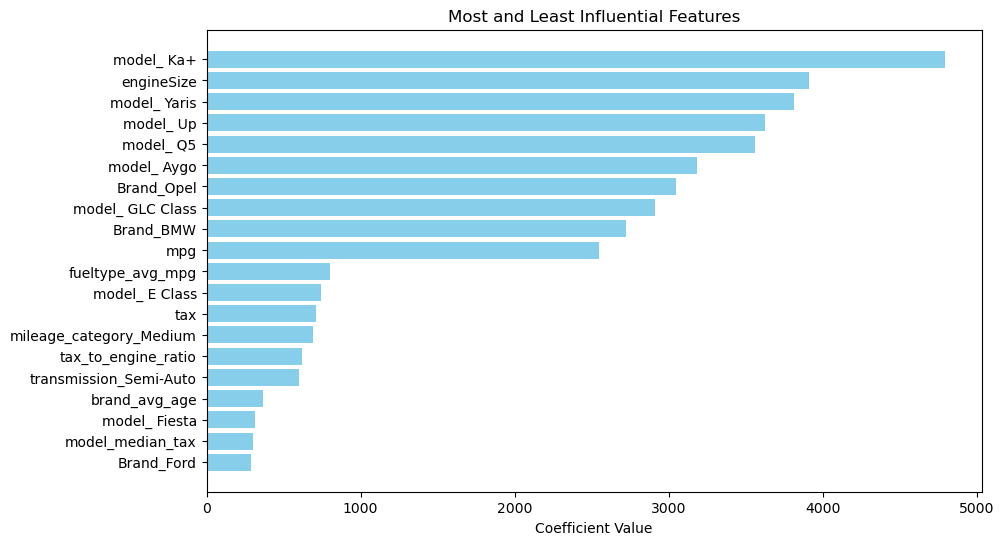

In [214]:
# Plot top 10 and bottom 10 variables
top_bottom = pd.concat([coefs_sorted.head(10), coefs_sorted.tail(10)])

plt.figure(figsize=(10,6))
plt.barh(top_bottom.index, top_bottom['coefs'], color='skyblue')
plt.xlabel('Coefficient Value')
plt.title('Most and Least Influential Features')
plt.gca().invert_yaxis()  # largest coef on top
plt.show()

## Ridge Regression

Ridge Regression is is a regularized version of Linear Regression that adds an L2 penalty on the coefficients. This helps prevent overfitting and can improve performance when features are correlated or highly variable. Ridge serves as a comparison to OLS, allowing us to evaluate the effect of L2 regularization. We will now implement this model.

In [215]:
# Create Ridge Regression model with fixed alpha
ridge_model = Ridge(alpha=1.0)

# Train the model
ridge_model = train_model(ridge_model, X_train, y_train)

# Evaluate on training and validation sets
train_metrics_ridge = evaluate_model(ridge_model, X_train, y_train)
val_metrics_ridge = evaluate_model(ridge_model, X_val, y_val)

# Display results
ridge_results = pd.DataFrame([train_metrics_ridge, val_metrics_ridge], index=['Train', 'Validation']).round(2).T
display(ridge_results)


,Train,Validation
R2,0.76,0.77
Adjusted R2,0.76,0.76
MAE,2920.58,2924.68
MSE,22506210.50,22229707.68
RMSE,4744.07,4714.84
MedAE,2066.37,2066.79
MAPE (%),0.21,0.21


## Lasso Regression

Lasso Regression is a linear regression method that adds an L1 penalty to the coefficients. This regularization can shrink some coefficients to zero, effectively performing feature selection and potentially simplifying the model. Lasso provides an alternative perspective to OLS and Ridge by emphasizing sparsity. We will now implement this model.

In [216]:
# Create Lasso regression model with fixed alpha
lasso_model = Lasso(alpha=1.0, max_iter=10000)

# Train the model
lasso_model = train_model(lasso_model, X_train, y_train)

# Evaluate on training and validation sets
train_metrics = evaluate_model(lasso_model, X_train, y_train)
val_metrics = evaluate_model(lasso_model, X_val, y_val)

# Combine metrics into a simple DataFrame
lasso_results = pd.DataFrame([train_metrics, val_metrics], index=['Train', 'Validation']).round(2).T
display(lasso_results)

,Train,Validation
R2,0.76,0.77
Adjusted R2,0.76,0.76
MAE,2920.86,2925.00
MSE,22507771.74,22231904.52
RMSE,4744.24,4715.07
MedAE,2068.76,2066.18
MAPE (%),0.21,0.21


## Elastic Net Regression

This technique combines both L1 and L2 penalties, balancing the effects of Lasso and Ridge regularization. This approach can be particularly useful when features are highly correlated or when both shrinkage and sparsity are desirable. Elastic Net allows us to explore how combined regularization impacts model performance. We will now implement this model.

In [217]:
# Create Elastic Net regression model with fixed alpha and l1_ratio
elastic_model = ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000)

# Train the model
elastic_model = train_model(elastic_model, X_train, y_train)

# Evaluate on training and validation sets
train_metrics_elastic = evaluate_model(elastic_model, X_train, y_train)
val_metrics_elastic = evaluate_model(elastic_model, X_val, y_val)

elastic_results = pd.DataFrame([train_metrics_elastic, val_metrics_elastic], index=['Train', 'Validation']).round(2).T
display(elastic_results)

,Train,Validation
R2,0.70,0.70
Adjusted R2,0.70,0.70
MAE,3251.10,3238.38
MSE,28860634.54,28769996.79
RMSE,5372.21,5363.77
MedAE,2304.74,2270.57
MAPE (%),0.22,0.22


## Model Comparison

After training and evaluating each regression model individually, we now compare their performance using key metrics. This comparison allows us to understand which model generalizes best to unseen data and whether regularization techniques like Ridge, Lasso, or Elastic Net offer improvements over standard Linear Regression.
By analyzing these metrics side by side, we can identify the most reliable model for predicting car resale prices and make informed decisions about potential adjustments or further tuning.

In [218]:
# List of models and their trained instances
models = {
    'OLS (Linear Regression)': lr_model,
    'Ridge': ridge_model,
    'Lasso': lasso_model,
    'Elastic Net': elastic_model
}

#Evaluate each model on the validation set and store results
results = {}
for name, model in models.items():
    results[name] = evaluate_model(model, X_val, y_val)

# Convert the results dictionary into a DataFrame
# Metrics as rows, models as columns
metrics_df = pd.DataFrame(results)

# Display the metrics
metrics_df.round(2)

,OLS (Linear Regression),Ridge,Lasso,Elastic Net
R2,0.77,0.77,0.77,0.70
Adjusted R2,0.76,0.76,0.76,0.70
MAE,2924.68,2924.68,2925.00,3238.38
MSE,22229671.59,22229707.68,22231904.52,28769996.79
RMSE,4714.84,4714.84,4715.07,5363.77
MedAE,2066.68,2066.79,2066.18,2270.57
MAPE (%),0.21,0.21,0.21,0.22


We compared four regression models—OLS, Ridge, Lasso, and Elastic Net—on training and validation data. With this comparison we conclude that the first three all perform similarly, explaining ~76% of the variance (R² ≈ 0.76) with consistent MAE and RMSE. 

We can also conlude that o overfitting is observed because the training and validation scores (R², MAE, RMSE) are very similar, indicating that the models generalize well and do not rely excessively on the training data. Regularization does not improve performance, suggesting low multicollinearity and few irrelevant features.

About the Elastic Net regression we can see that has lower performance (R² ≈ 0.70, higher errors) due to over regularization. This method requires tuning of alpha and l1_ratio.

Overall, OLS provides a strong baseline. Ridge and Lasso offer no significant improvement and Elastic Net needs parameter adjustment to match other models.

!!!! O CHAT DEU BUÉ IDEIAS DE GRÁFICOS QUE PODEMOS POR SE QUISERMOS 

# Test Models

In [219]:
# Predict using all models on the test set
test_predictions = {
    'OLS': lr_model.predict(test),
    'Ridge': ridge_model.predict(test),
    'Lasso': lasso_model.predict(test),
    'Elastic Net': elastic_model.predict(test)
}

# Convert to a DataFrame for easy comparison
test_predictions_df = pd.DataFrame(test_predictions, index=test.index)

# Show the first few predictions
test_predictions_df.head(10)

,OLS,Ridge,Lasso,Elastic Net
0,19637.616205,19640.622053,19743.863359,21869.461198
1,19483.986972,19483.240304,19476.629857,19258.247850
2,14448.732629,14448.567956,14453.865743,16365.753468
3,15899.028789,15898.883949,15891.819179,16614.860458
4,28033.485848,28034.371347,28046.187804,27327.549944
5,8087.957896,8088.136608,8111.581483,9420.268445
6,14353.735451,14354.401680,14361.227290,16053.413239
7,17651.079514,17651.729758,17655.835437,18774.215276
8,2569.747885,2568.627107,2535.137701,4244.002652
9,17340.498054,17340.655006,17347.204155,19256.139622


In [221]:
test_predictions

{'OLS': array([19637.61620538, 19483.98697247, 14448.73262915, ...,
        35397.20234401, 19594.09594897, 12454.18828222]),
 'Ridge': array([19640.62205265, 19483.24030404, 14448.56795629, ...,
        35388.5561073 , 19595.68394754, 12456.33556372]),
 'Lasso': array([19743.8633595 , 19476.62985707, 14453.86574316, ...,
        35259.78704339, 19605.96894528, 12470.46925954]),
 'Elastic Net': array([21869.46119798, 19258.24785041, 16365.75346756, ...,
        27903.68741539, 19610.49134721, 12943.53286601])}

## Save results to use in Kaggle

In [223]:
# Go one level up from the notebooks folder to reach the repo root
selected_dir = "../results/kaggle_submissions/"
os.makedirs(selected_dir, exist_ok=True)

In [229]:
# Extract car IDs
car_ids = test.index.values

# Save OLS predictions
ols_df = pd.DataFrame({
    'carIDID': car_ids,
    'price': test_predictions['OLS']
})

# Save to CSV
ols_df.to_csv(f"{selected_dir}/ols_predictions.csv", index=False)


# Save Ridge predictions
ridge_df = pd.DataFrame({
    'carIDID': car_ids,
    'price': test_predictions['Ridge']
})

# Save to CSV
ridge_df.to_csv(f"{selected_dir}/ridge_predictions.csv", index=False)
